In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv("nhanes_cardiometabolic_subset_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10175, 64)


,SEQN,BPXSY1,BPXSY2,BPXSY3,BPXSY4,BPXDI1,BPXDI2,BPXDI3,BPXDI4,BPXPULS,...,PAQ605,PAQ620,PAD615,PAQ650,DBQ010,DBQ700,SLQ050,SLQ060,HSD010,BPQ080
0,73557,122.0,114.0,102.0,NaN,72.0,76.0,74.0,NaN,1.0,...,2.0,2.0,NaN,2.0,NaN,2.0,1.0,2.0,2.0,1.0
1,73558,156.0,160.0,156.0,NaN,62.0,80.0,42.0,NaN,1.0,...,2.0,1.0,NaN,2.0,NaN,3.0,2.0,2.0,4.0,1.0
2,73559,140.0,140.0,146.0,NaN,90.0,76.0,80.0,NaN,1.0,...,2.0,1.0,NaN,2.0,NaN,3.0,2.0,2.0,3.0,1.0
3,73560,108.0,102.0,104.0,NaN,38.0,34.0,38.0,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,73561,136.0,134.0,142.0,NaN,86.0,88.0,86.0,NaN,1.0,...,2.0,1.0,NaN,2.0,NaN,2.0,2.0,2.0,5.0,2.0


In [5]:
bp_vars = [
    "BPXSY1","BPXSY2","BPXSY3","BPXSY4",
    "BPXDI1","BPXDI2","BPXDI3","BPXDI4",
    "BPXPULS",
    "BPQ020","BPQ030","BPQ080",
    "BP_CATEGORY","HTN_STAGE"
]

df = df.drop(columns=bp_vars, errors="ignore")

print("Shape after removing BP variables:", df.shape)

Shape after removing BP variables: (10175, 50)


In [7]:
# define target variable
target = "HYPERTENSION_YN"

In [9]:
# separate predictors and target
X = df.drop(columns=[target])
y = df[target]

In [11]:
# missing summary
missing = X.isnull().sum()
missing_pct = (X.isnull().mean()*100).round(2)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_pct
}).sort_values("Missing_Percent", ascending=False)

print("Top missing variables:\n")
print(missing_summary.head(15))

print("\nVariables with any missing data:", (missing>0).sum())

Top missing variables:

              Missing_Count  Missing_Percent
PAD615                 9007            88.52
DIQ070                 8975            88.21
BPQ050A                8360            82.16
DBQ010                 8310            81.67
SMQ040                 7596            74.65
URXUCR                 7485            73.56
ACR_MG_PER_G           7485            73.56
LBXIN                  7082            69.60
LBDLDL                 7070            69.48
RATIO_TG_HDL           7029            69.08
LBXTR                  7029            69.08
ALQ120U                6582            64.69
ALQ120Q                5696            55.98
DMDEDUC2               4406            43.30
DMDMARTL               4406            43.30

Variables with any missing data: 45


In [13]:
drop_missing = [
    "PAD615",
    'DIQ070',
    'BPQO5OA',
    'DBQ010',
    "SMQ040",
    "LBXIN",
    "LBDLDL",
    "RATIO_TG_HDL",
    "LBXTR",
    "ALQ120U",
    "ALQ120Q"
]

df = df.drop(columns=[c for c in drop_missing if c in df.columns])

print("Dataset shape after removing high-missing variables:", df.shape)

Dataset shape after removing high-missing variables: (10175, 40)


In [15]:
target = "HYPERTENSION_YN"

X = df.drop(columns=[target])
y = df[target]

print("Total predictors:", X.shape[1])

Total predictors: 39


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (8140, 39)
Test shape: (2035, 39)


In [19]:
numeric_features = X_train.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object","category"]).columns.tolist()

print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))

Numeric predictors: 39
Categorical predictors: 0


In [21]:
# convert categorical variables

categorical_vars = [
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "DIQ010",
    "DIQ050",
    "SMQ020",
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "DBQ700",
    "SLQ050",
    "SLQ060",
    "HSD010",
    "BPQ080"
]

for col in categorical_vars:
    if col in df.columns:
        df[col] = df[col].astype("category")

print("Categorical conversion complete.")

Categorical conversion complete.


In [23]:
X = df.drop(columns=[target])
y = df[target]

numeric_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["category","object"]).columns.tolist()

print("Numeric predictors:", len(numeric_features))
print("Categorical predictors:", len(categorical_features))

Numeric predictors: 25
Categorical predictors: 14


In [25]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessing = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [27]:
log_model = Pipeline([
    ("preprocess", preprocessing),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SEQN', 'BPXSY_AVG',
                                                   'BPXDI_AVG', 'BPQ050A',
                                                   'RIDAGEYR', 'INDFMPIR',
                                                   'BMXWT', 'BMXHT', 'BMXBMI',
                                                   'BMXWAIST', 'BMXARML',
                                                   'BMXARMC', 'BMXLEG', 'LBXGH',
                                                   'LBXTC', 'LBDHDD',
                                                   'RATIO_TC_HDL', 'LBXSCR',
                                                   'URXUMA', 'UR...
                                                   'ACR_MG_PER_G', 'LBXSAL',
                                                   'LBXWBCSI', 'LBXPLTSI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['RIAGENDR', 'RIDRETH1',
                                                   'DMDEDUC2', 'DMDMARTL',
                                                   'DIQ010', 'DIQ050', 'SMQ020',
                                                   'PAQ605', 'PAQ620', 'PAQ650',
                                                   'DBQ700', 'SLQ050', 'SLQ060',
                                                   'HSD010'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [29]:
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8943488943488943
Precision: 0.8291873963515755
Recall: 0.8169934640522876
F1 Score: 0.823045267489712

Confusion Matrix:
[[1320  103]
 [ 112  500]]


In [31]:
rf_model = Pipeline([
    ("preprocess", preprocessing),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SEQN', 'BPXSY_AVG',
                                                   'BPXDI_AVG', 'BPQ050A',
                                                   'RIDAGEYR', 'INDFMPIR',
                                                   'BMXWT', 'BMXHT', 'BMXBMI',
                                                   'BMXWAIST', 'BMXARML',
                                                   'BMXARMC', 'BMXLEG', 'LBXGH',
                                                   'LBXTC', 'LBDHDD',
                                                   'RATIO_TC_HDL', 'LBXSCR',
                                                   'URXUMA', 'UR...
                                                   'LBXWBCSI', 'LBXPLTSI']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['RIAGENDR', 'RIDRETH1',
                                                   'DMDEDUC2', 'DMDMARTL',
                                                   'DIQ010', 'DIQ050', 'SMQ020',
                                                   'PAQ605', 'PAQ620', 'PAQ650',
                                                   'DBQ700', 'SLQ050', 'SLQ060',
                                                   'HSD010'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [32]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.9208845208845209
Precision: 0.8881239242685026
Recall: 0.8431372549019608
F1 Score: 0.865046102263202

Confusion Matrix:
[[1358   65]
 [  96  516]]


In [35]:
gb_model = Pipeline([
    ("preprocess", preprocessing),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SEQN', 'BPXSY_AVG',
                                                   'BPXDI_AVG', 'BPQ050A',
                                                   'RIDAGEYR', 'INDFMPIR',
                                                   'BMXWT', 'BMXHT', 'BMXBMI',
                                                   'BMXWAIST', 'BMXARML',
                                                   'BMXARMC', 'BMXLEG', 'LBXGH',
                                                   'LBXTC', 'LBDHDD',
                                                   'RATIO_TC_HDL', 'LBXSCR',
                                                   'URXUMA', 'UR...
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['RIAGENDR', 'RIDRETH1',
                                                   'DMDEDUC2', 'DMDMARTL',
                                                   'DIQ010', 'DIQ050', 'SMQ020',
                                                   'PAQ605', 'PAQ620', 'PAQ650',
                                                   'DBQ700', 'SLQ050', 'SLQ060',
                                                   'HSD010'])])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=200,
                                            random_state=42))])

In [36]:
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting Results
Accuracy: 0.9267813267813267
Precision: 0.918625678119349
Recall: 0.8300653594771242
F1 Score: 0.8721030042918455

Confusion Matrix:
[[1378   45]
 [ 104  508]]


In [37]:
auc_scores = cross_val_score(
    gb_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross-validation AUC scores:", auc_scores)
print("Mean AUC:", auc_scores.mean().round(3))
print("Std Dev:", auc_scores.std().round(3))

Cross-validation AUC scores: [0.97602414 0.97720915 0.97739517 0.97677454 0.97906648]
Mean AUC: 0.977
Std Dev: 0.001


In [43]:
# get trained random forest model
gb_classifier = gb_model.named_steps["model"]

# get feature names after preprocessing
feature_names = gb_model.named_steps["preprocess"].get_feature_names_out()

In [47]:
# create importance series
importance = pd.Series(gb_classifier.feature_importances_, index=feature_names)

In [49]:
# clean names a little
importance.index = importance.index.str.replace("num__", "", regex=False)
importance.index = importance.index.str.replace("cat__", "", regex=False)

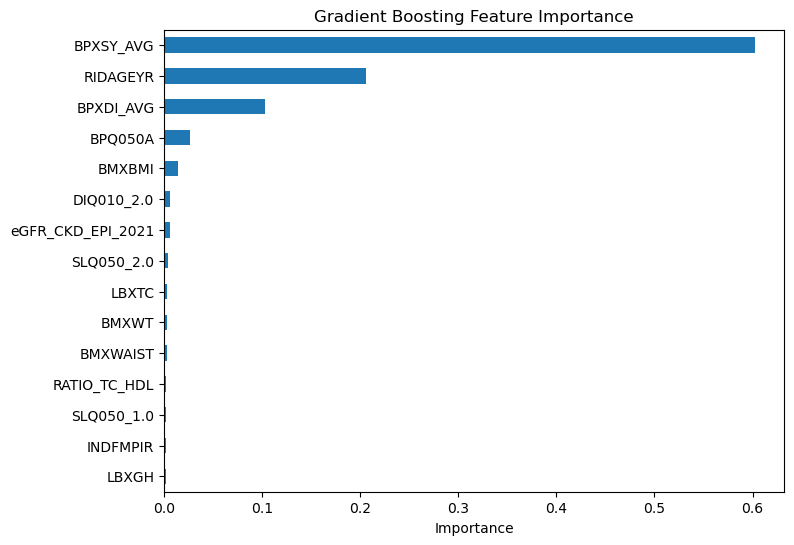

In [53]:
import matplotlib.pyplot as plt

# top 15 features
top_features = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh")
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.show()

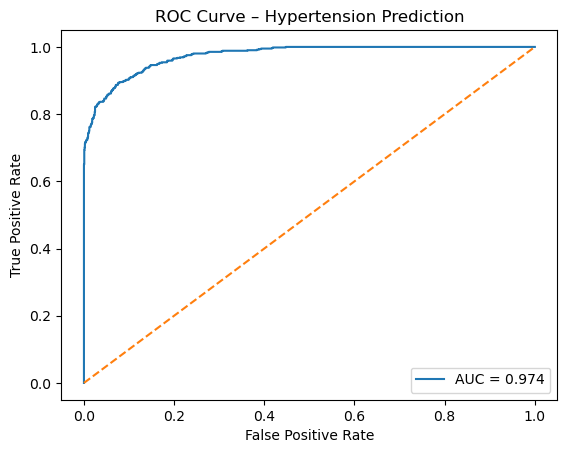

In [61]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Hypertension Prediction")
plt.legend()
plt.show()

In [59]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities
y_prob = gb_model.predict_proba(X_test)[:,1]

# ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("ROC AUC:", round(auc_score,3))

ROC AUC: 0.974
